# Analiza podatkov

Uvozimo prvo knjižnico Pandas in vzemimo podatke iz CSV datotek.

Uvozimo še knjižnico ipywidgets, ki jo bomo uporabili za interaktivne menije.

In [2]:
import pandas as pd
import ipywidgets as widgets


stat = pd.read_csv("CSV_datoteke/statistika.csv")
konf = pd.read_csv("CSV_datoteke/konference.csv")
raz = pd.read_csv("CSV_datoteke/razsirjeno.csv")

Združimo skupaj tabele, saj bomo za nekatere grafe potrebovali podatke iz večih tabel.

In [3]:
konf_2 = konf.drop(columns=["ime"])
raz_2 = raz.drop(columns=["ime"])
tabela = stat.merge(konf_2, on=["id", "leto"]).merge(raz_2, on=["id", "leto"])

### 1. del - evolucija v času 1980 - 2026

Poglejmo si tabelo "statistika":

In [4]:
with pd.option_context("display.max_rows", 10):
    display(stat)

,id,ime,leto,odigrane minute,meti 3 točke,poskusi 3 točke,meti 2 točki,poskusi 2 točki,prosti meti,poskusi prostih metov,skoki v napadu,skoki v obrambi,asistence,ukradene žoge,blokade,izgubljene žoge,osebni prekrški
0,SAS,San Antonio Spurs,1980,19755,52,206,3804,7532,2024,2528,1153,2515,2326,771,333,1589,2103
1,LAL,Los Angeles Lakers,1980,19880,20,100,3878,7268,1622,2092,1085,2653,2413,774,546,1639,1784
2,CLE,Cleveland Cavaliers,1980,19930,36,187,3775,7854,1702,2205,1307,2381,2108,764,342,1370,1934
3,NYK,New York Knicks,1980,19780,42,191,3760,7481,1698,2274,1236,2303,2265,881,457,1613,2168
4,BOS,Boston Celtics,1980,19880,162,422,3455,6965,1907,2449,1227,2457,2198,809,308,1539,1974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,PHO,Phoenix Suns,2026,19755,1210,3348,2152,4041,1298,1663,1064,2471,2021,781,347,1188,1691
1310,IND,Indiana Pacers,2026,19755,1097,3084,2249,4220,1430,1842,806,2633,2269,605,374,1190,1710
1311,SAC,Sacramento Kings,2026,19755,843,2476,2565,4823,1443,1870,943,2523,2095,658,372,1175,1614
1312,MIL,Milwaukee Bucks,2026,19755,1240,3205,2105,3807,1142,1564,731,2610,2116,607,326,1247,1617


Hitro lahko opazimo, da se je čez leta število metov za tri točke močno povečalo. 

Poglejmo si, kako se povprečno število zadetih metov za tri točke spreminja čez leta in dodajmo zraven še povprečno število metov za dve točki in proste mete. Ker je število tekem v rednem delu v nekaterih letih manjše od standardnega, poglejmo število metov na tekmo.

Vzemimo skupno tabelo in ustvarimo nov stolpec z imenom "število iger".

In [5]:
tabela["število iger"] = tabela["zmage"] + tabela["porazi"]

Združimo podatke po letih in jih prikažimo z grafom.

<Axes: title={'center': 'Zadeti meti na igro skozi leta'}, xlabel='Leto', ylabel='Število metov  na igro'>

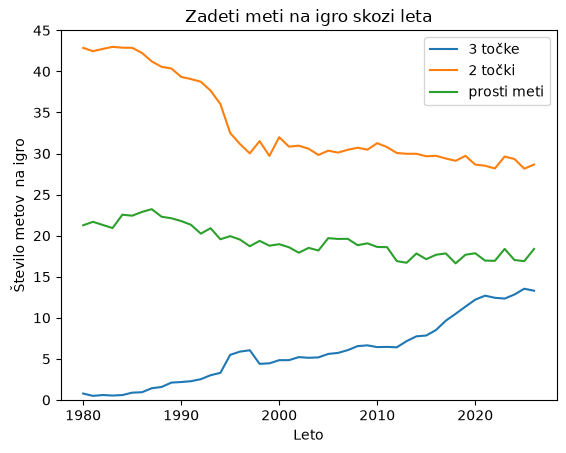

In [6]:
tocke = tabela.groupby("leto")[["meti 3 točke", "meti 2 točki", "prosti meti", "število iger"]].mean()

tocke["3 točke na tekmo"] = (tocke["meti 3 točke"] / tocke["število iger"])
tocke["2 točki na tekmo"] = (tocke["meti 2 točki"] / tocke["število iger"])
tocke["prosti meti na tekmo"] = (tocke["prosti meti"] / tocke["število iger"])

graf1 = tocke.plot(
    y=["3 točke na tekmo", "2 točki na tekmo", "prosti meti na tekmo"],
    title="Zadeti meti na igro skozi leta",
    xlabel="Leto",
    ylabel="Število metov  na igro"
)

graf1.set_ylim(0, 45)
graf1.legend(["3 točke", "2 točki", "prosti meti"])
graf1

Res, lahko vidimo, da se je število metov za tri točke povečalo, hkrati se pa je število metov za dve točki ustrezno zmanjšalo.  

To lahko pojasnimo s tem, da so šele v sezoni 1979/80 uvedli mete za tri točke. Na začetku so bili dolgi meti košarkašem tuji, ščasoma pa so se taktike spremenile in dale večji pomen daljšim metom.

Število prostih metov pa se ni kaj preveč spremenilo.

___


Poglejmo si zdaj še razmerje med uspešnimi meti in poskusi metov. Ustvarimo novo tabelo s poskusi metov in jo združimo s prejšnjo tabelo.

<Axes: title={'center': 'Razmerje med zadetimi meti in poskusi metov skozi leta'}, xlabel='Leto', ylabel='Delež uspelih metov'>

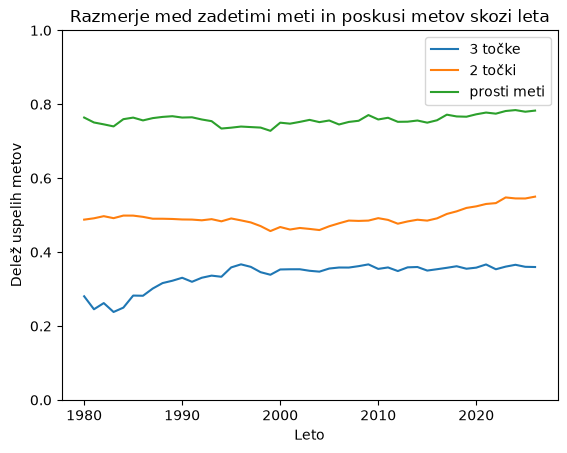

In [7]:
poskusi = tabela.groupby("leto")[["poskusi 3 točke", "poskusi 2 točki", "poskusi prostih metov"]].mean()

tocke_poskusi = tocke.merge(poskusi, on="leto")
tocke_poskusi["razmerje 3 točke"] = tocke_poskusi["meti 3 točke"] / tocke_poskusi["poskusi 3 točke"]
tocke_poskusi["razmerje 2 točki"] = tocke_poskusi["meti 2 točki"] / tocke_poskusi["poskusi 2 točki"]
tocke_poskusi["razmerje prosti meti"] = tocke_poskusi["prosti meti"] / tocke_poskusi["poskusi prostih metov"]

graf2 = tocke_poskusi.plot(
    y=["razmerje 3 točke", "razmerje 2 točki", "razmerje prosti meti"],
    title="Razmerje med zadetimi meti in poskusi metov skozi leta",
    xlabel="Leto",
    ylabel="Delež uspelih metov"
)

graf2.set_ylim(0, 1)
graf2.legend(["3 točke", "2 točki", "prosti meti"])
graf2

Vidimo, da so košarkaši dosti bolj uspešni pri izvajanju prostih metov kot pa metov v igri. To je smiselno, saj so prosti meti izvedeni mirujoči in vedno iz istega mesta.

Tudi tukaj nam podatki kažejo, da košarkaši na začetku niso bili vajeni dolgih metov, saj se je delež uspešnih metov za tri točke stabiliziral šele okoli leta 2000.

Delež uspešnih prostih metov je bolj ali manj isti čez vsa leta, trend za uspešne mete za dve točki pa v zadnjem desetletju kaže rahlo navzgor.

___

V tabeli "konference" imamo za vsako ekipo podatek o povprečnih danih in prejetih točkah na tekmo. 

In [8]:
with pd.option_context("display.max_rows", 10):
    povp_tocke = konf.iloc[:, [0, 1, 2, 7, 8]]
    display(povp_tocke)


,id,ime,leto,povprečne dane točke,povprečne prejete točke
0,BOS,Boston Celtics,1980,113.5,105.7
1,PHI,Philadelphia 76ers,1980,109.1,104.9
2,WSB,Washington Bullets,1980,107.0,109.5
3,NYK,New York Knicks,1980,114.0,115.1
4,NJN,New Jersey Nets,1980,108.3,109.5
...,...,...,...,...,...
1309,SAS,San Antonio Spurs,2026,119.8,111.5
1310,HOU,Houston Rockets,2026,115.2,110.0
1311,NOP,New Orleans Pelicans,2026,115.5,120.0
1312,DAL,Dallas Mavericks,2026,114.1,119.6


Poglejmo si, kako sta se ta dva podatka spreminjala za posamezne ekipe skozi čas.

Ustvaril bom interaktivni meni, v katerem lahko izberete ekipo, in prikazal se vam bo ustrezen graf.

In [11]:
meni = widgets.Dropdown(
    options = povp_tocke["ime"].unique(),
    description = "Ekipa:"
    )


def narisi(ekipa):
    podatki = povp_tocke[povp_tocke["ime"] == ekipa]

    podatki.plot(
        x="leto",
        y=["povprečne dane točke", "povprečne prejete točke"],
        title=f"Povprečne dane/prejete točke na tekmo za ekipo {ekipa}",
        marker="s",
        ylabel="točke"
    )

widgets.interact(narisi, ekipa=meni)

interactive(children=(Dropdown(description='Ekipa:', options=('Boston Celtics', 'Philadelphia 76ers', 'Washing…

<function __main__.narisi(ekipa)>